# **Региональный анализ потенциала внедрения ИИ**

## 1. Установка библиотек и параметры

In [1]:
!pip install -q linearmodels
!pip install -q econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 12.8 MB/s eta 0:00:00


In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from IPython.display import display
from scipy.stats import chi2, norm
from statsmodels.tsa.stattools import adfuller

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

RANDOM_STATE = 42
LATEST_YEAR = 2024
MIN_AI_COVERAGE = 0.60
READINESS_MODEL_COL = "ITG_equal_0_100"

def find_input(patterns):
    for folder in [Path("/content"), Path("/mnt/data")]:
        for pattern in patterns:
            files = sorted(folder.glob(pattern))
            if files:
                return files[0]
    raise FileNotFoundError("Не найден файл: " + ", ".join(patterns))

REGIONAL_FILE = find_input(["Регионы_с_OKATO.xlsx"])
SECTOR_FILE = find_input(["AI_интенсивность_7_секторов*.csv"])

OUTPUT_DIR = REGIONAL_FILE.parent / "Результаты_регионального_анализа"
FIGURES_DIR = OUTPUT_DIR / "Графики"
TABLES_DIR = OUTPUT_DIR / "Таблицы"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Региональные данные:", REGIONAL_FILE)
print("Данные семи секторов:", SECTOR_FILE)
print("Папка результатов:", OUTPUT_DIR)

Региональные данные: /content/Регионы_с_OKATO.xlsx
Данные семи секторов: /content/AI_интенсивность_7_секторов.csv
Папка результатов: /content/Результаты_регионального_анализа


## 2. Загрузка и проверка данных

In [5]:
regional = pd.read_excel(REGIONAL_FILE, sheet_name="Данные")
sector_exposure = pd.read_csv(SECTOR_FILE)

required = [
    "region", "year", "grp_real_2024_mln_rub", "labor_force_thousand_people",
    "internet_use_pct", "pc_use_pct", "innovation_activity_pct",
    "rnd_internal_costs_real_2024", "innovation_costs_mln_rub_real_2024",
    "patents_patent_applications_inventions", "researchers_with_degrees_count",
    "rnd_personnel_count", "salary_real_2024_rub", "unemployment_rate_pct",
    "organizations_total_count"
]

missing = [col for col in required if col not in regional.columns]
if missing:
    raise KeyError("Нет обязательных столбцов: " + ", ".join(missing))

regional["year"] = pd.to_numeric(regional["year"], errors="coerce").astype("Int64")
regional = regional.dropna(subset=["region", "year"]).copy()
regional["year"] = regional["year"].astype(int)
regional = regional.sort_values(["region", "year"]).reset_index(drop=True)

duplicates = regional.duplicated(["region", "year"]).sum()
if duplicates:
    raise ValueError(f"Обнаружено дубликатов регион–год: {duplicates}")

print("Наблюдений:", len(regional))
print("Регионов:", regional["region"].nunique())
print("Период:", regional["year"].min(), "–", regional["year"].max())
display(sector_exposure)

Наблюдений: 1659
Регионов: 79
Период: 2004 – 2024


,vrp_sector,sector_name,sector_AI_intensity,n_okved,n_complete_okved,mean_data_quality
0,добыча_полезных_ископаемых,Добыча полезных ископаемых,8.4795,5,3,0.8000
1,недвижимость_проф_научные_и_адм_услуги,"Профессиональные, научные и административные у...",78.7357,5,4,0.9500
2,обрабатывающие_производства,Обрабатывающие производства,58.2025,16,14,0.9531
3,сельское_лесное_хозяйство_рыболовство,"Сельское и лесное хозяйство, рыболовство",10.2387,3,3,1.0000
4,строительство,Строительство,8.1512,3,0,0.7500
5,торговля_ремонт,Торговля и ремонт,37.6819,3,3,1.0000
6,транспорт_связь_информация,"Транспорт, связь и информация",59.0584,5,2,0.6000


## 3. Производительность и структура региональной экономики

Производительность рассчитывается как реальный ВРП на одного участника рабочей силы:

$$
Productivity_{r,t}=
\frac{RealGRP_{r,t}}{LaborForce_{r,t}}.
$$

Темп роста:

$$
Growth_{r,t}=100\Delta\ln(Productivity_{r,t}).
$$

Отраслевая концентрация:

$$
HHI_{r,t}=\sum_s Share_{r,s,t}^{2},
\qquad
EffectiveSectors_{r,t}=\frac{1}{HHI_{r,t}}.
$$

In [6]:
regional = regional.sort_values(["region", "year"]).reset_index(drop=True)

# Производительность труда
regional["productivity_thousand_rub"] = regional["grp_real_2024_mln_rub"] / regional["labor_force_thousand_people"]
regional.loc[regional["productivity_thousand_rub"] <= 0, "productivity_thousand_rub"] = np.nan
regional["ln_productivity"] = np.log(regional["productivity_thousand_rub"])

# Годовой темп роста
regional["year_gap"] = regional.groupby("region")["year"].diff()
regional["productivity_growth_pct"] = 100 * regional.groupby("region")["ln_productivity"].diff()
regional.loc[regional["year_gap"] != 1, "productivity_growth_pct"] = np.nan

# Структура экономики
industry_cols = [col for col in regional.columns if col.startswith("grp_industry_") and col.endswith("_real_2024")]
industry_values = regional[industry_cols].clip(lower=0)
industry_total = industry_values.sum(axis=1)

regional["industry_coverage_total"] = industry_total / regional["grp_real_2024_mln_rub"]
industry_shares = industry_values.div(industry_total.replace(0, np.nan), axis=0)

regional["HHI"] = industry_shares.pow(2).sum(axis=1)
regional["effective_sectors"] = 1 / regional["HHI"].replace(0, np.nan)

cols = [
    "region", "year", "productivity_thousand_rub",
    "productivity_growth_pct", "industry_coverage_total",
    "HHI", "effective_sectors"
]

display(regional[cols].head(10))

,region,year,productivity_thousand_rub,productivity_growth_pct,industry_coverage_total,HHI,effective_sectors
0,Алтайский край,2004,447.2900,NaN,1.0000,0.1423,7.0295
1,Алтайский край,2005,471.2169,5.2111,1.0000,0.1363,7.3356
2,Алтайский край,2006,557.4430,16.8042,1.0000,0.1309,7.6399
3,Алтайский край,2007,648.5239,15.1339,1.0000,0.1370,7.3002
4,Алтайский край,2008,659.3953,1.6624,1.0000,0.1294,7.7268
5,Алтайский край,2009,626.0632,-5.1872,1.0000,0.1277,7.8335
6,Алтайский край,2010,651.6494,4.0055,1.0000,0.1337,7.4771
7,Алтайский край,2011,702.4040,7.5002,1.0000,0.1247,8.0205
8,Алтайский край,2012,742.9952,5.6181,1.0000,0.1202,8.3195
9,Алтайский край,2013,817.2331,9.5235,1.0000,0.1227,8.1528


## 4. Региональная структурная AI-интенсивность

Для каждого региона отраслевые оценки взвешиваются по структуре ВРП:

$$
StructuralAI_{r,t}=
\frac{
\sum_g GRP_{r,g,t}\cdot SectorAI_g
}{
\sum_g GRP_{r,g,t}
}.
$$

Покрытие:

$$
Coverage_{r,t}=
\frac{\sum_g GRP_{r,g,t}}{GRP_{r,t}}.
$$

In [8]:
sector_exposure["sector_AI_intensity"] = pd.to_numeric(
    sector_exposure["sector_AI_intensity"], errors="coerce"
)

if sector_exposure["sector_AI_intensity"].isna().any():
    raise ValueError("В AI-интенсивности секторов есть пропуски.")

weighted_sum = pd.Series(0.0, index=regional.index)
covered_sum = pd.Series(0.0, index=regional.index)

for row in sector_exposure.itertuples():
    col = f"grp_industry_{row.vrp_sector}_real_2024"

    if col not in regional.columns:
        raise KeyError(f"Нет региональной колонки: {col}")

    sector_grp = regional[col].clip(lower=0)
    weighted_sum += sector_grp * row.sector_AI_intensity
    covered_sum += sector_grp

regional["sector_coverage"] = covered_sum / regional["grp_real_2024_mln_rub"]
regional["structural_AI_intensity"] = weighted_sum / covered_sum.replace(0, np.nan)

print("Среднее покрытие:", f'{regional["sector_coverage"].mean():.1%}')
print("Медианное покрытие:", f'{regional["sector_coverage"].median():.1%}')
print("Наблюдений с покрытием ≥ порога:", int((regional["sector_coverage"] >= MIN_AI_COVERAGE).sum()))

display(regional[[
    "region", "year", "structural_AI_intensity", "sector_coverage"
]].head())

Среднее покрытие: 76.4%
Медианное покрытие: 77.5%
Наблюдений с покрытием ≥ порога: 1589


,region,year,structural_AI_intensity,sector_coverage
0,Алтайский край,2004,37.0351,0.7583
1,Алтайский край,2005,40.0220,0.7591
2,Алтайский край,2006,40.6148,0.7587
3,Алтайский край,2007,40.8558,0.7699
4,Алтайский край,2008,41.2398,0.7581


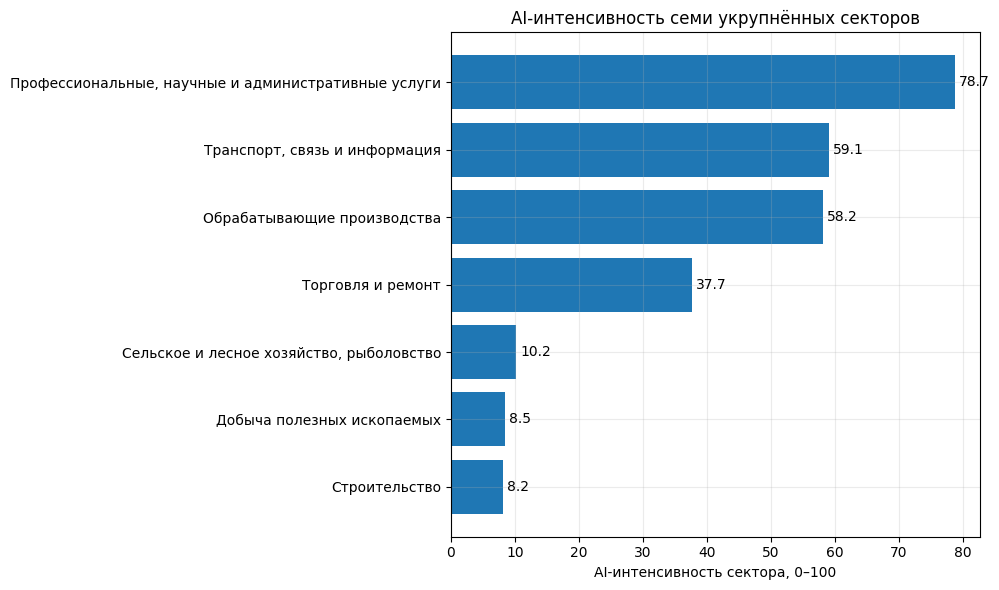

In [10]:
sector_plot = sector_exposure.sort_values("sector_AI_intensity")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sector_plot["sector_name"], sector_plot["sector_AI_intensity"])

for bar, value in zip(bars, sector_plot["sector_AI_intensity"]):
    ax.text(value + 0.6, bar.get_y() + bar.get_height() / 2, f"{value:.1f}", va="center")

ax.set_xlabel("AI-интенсивность сектора, 0–100")
ax.set_title("AI-интенсивность семи укрупнённых секторов")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "AI_интенсивность_семи_секторов.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Индекс технологической готовности

Используются пять блоков:

- $D$ — цифровая инфраструктура;
- $S$ — наука и исследования;
- $I$ — инновационная активность;
- $H$ — человеческий капитал и рынок труда;
- $T$ — структурная устойчивость.

Основной индекс:

$$
ITG_{r,t}=0.2D_{r,t}+0.2S_{r,t}+0.2I_{r,t}+0.2H_{r,t}+0.2T_{r,t}.
$$

PCA используется как альтернативная проверка устойчивости.

In [11]:
# Относительные показатели науки и инноваций
regional["rnd_intensity"] = regional["rnd_internal_costs_real_2024"] / regional["grp_real_2024_mln_rub"]
regional["innovation_intensity"] = regional["innovation_costs_mln_rub_real_2024"] / regional["grp_real_2024_mln_rub"]
regional["patents_per_100k_labor_force"] = regional["patents_patent_applications_inventions"] / regional["labor_force_thousand_people"] * 100
regional["researchers_degree_per_10k_labor_force"] = regional["researchers_with_degrees_count"] / regional["labor_force_thousand_people"] * 10
regional["rnd_personnel_per_10k_labor_force"] = regional["rnd_personnel_count"] / regional["labor_force_thousand_people"] * 10

readiness_features = {
    "D": ["internet_use_pct", "pc_use_pct"],
    "S": ["rnd_intensity", "researchers_degree_per_10k_labor_force", "rnd_personnel_per_10k_labor_force"],
    "I": ["innovation_activity_pct", "innovation_intensity", "patents_per_100k_labor_force"]
}

all_features = [col for features in readiness_features.values() for col in features]

# Приведение к числовому формату и заполнение пропусков
for col in all_features:
    regional[col] = pd.to_numeric(regional[col], errors="coerce")
    regional[col] = regional.groupby("region")[col].transform(
        lambda x: x.interpolate(limit_area="inside")
    )
    regional[col] = regional[col].fillna(
        regional.groupby("year")[col].transform("median")
    )

# Нормирование показателей в шкалу 0–100
for col in all_features:
    regional[f"{col}_score"] = regional[col].rank(method="average", pct=True) * 100

# Расчёт блоков
for block, features in readiness_features.items():
    score_cols = [f"{col}_score" for col in features]
    regional[f"ITG_{block}"] = regional[score_cols].mean(axis=1)

# Итоговый индекс равных весов
block_cols = ["ITG_D", "ITG_S", "ITG_I"]
regional["ITG_equal_0_100"] = regional[block_cols].mean(axis=1)

display(regional[[
    "region", "year", "ITG_D", "ITG_S",
    "ITG_I", "ITG_equal_0_100"
]].head(10).round(2))

,region,year,ITG_D,ITG_S,ITG_I,ITG_equal_0_100
0,Алтайский край,2004,5.6400,31.6500,39.1800,25.4900
1,Алтайский край,2005,15.9600,31.3600,49.8500,32.3900
2,Алтайский край,2006,20.5500,34.8400,48.5200,34.6400
3,Алтайский край,2007,20.2100,35.4200,51.2400,35.6200
4,Алтайский край,2008,20.2800,30.4800,37.6300,29.4700
5,Алтайский край,2009,23.0000,27.7300,36.0900,28.9400
6,Алтайский край,2010,28.3200,26.0400,39.9300,31.4300
7,Алтайский край,2011,28.6600,37.0900,57.8600,41.2000
8,Алтайский край,2012,30.1400,48.9700,54.9200,44.6800
9,Алтайский край,2013,32.3500,54.4100,52.9600,46.5800


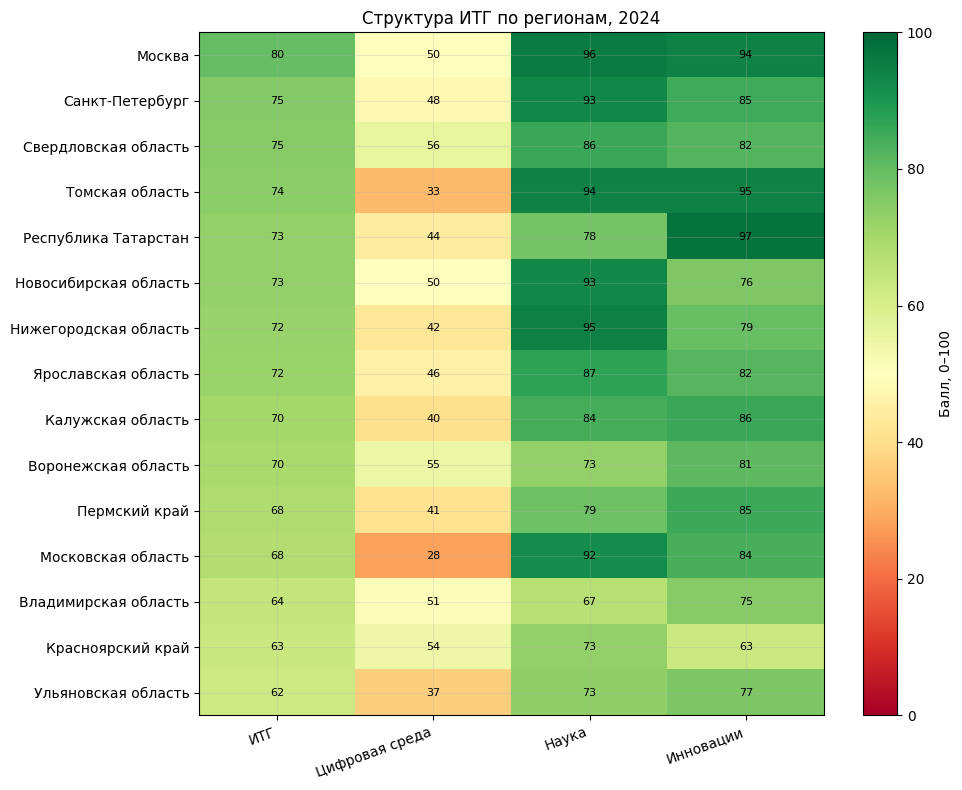

In [12]:
latest_itg = regional[regional["year"] == LATEST_YEAR].dropna(subset=[READINESS_MODEL_COL]).copy()
strengths = latest_itg.nlargest(15, READINESS_MODEL_COL).copy()

cols = ["ITG_equal_0_100", "ITG_D", "ITG_S", "ITG_I"]
labels = ["ИТГ", "Цифровая среда", "Наука", "Инновации"]
matrix = strengths[cols].to_numpy()

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(matrix, aspect="auto", vmin=0, vmax=100, cmap="RdYlGn")

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_yticks(range(len(strengths)))
ax.set_yticklabels(strengths["region"])

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f"{matrix[i, j]:.0f}", ha="center", va="center", fontsize=8)

ax.set_title(f"Структура ИТГ по регионам, {LATEST_YEAR}")

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Балл, 0–100")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "Структура_ИТГ_по_регионам.png", dpi=200, bbox_inches="tight")
plt.show()

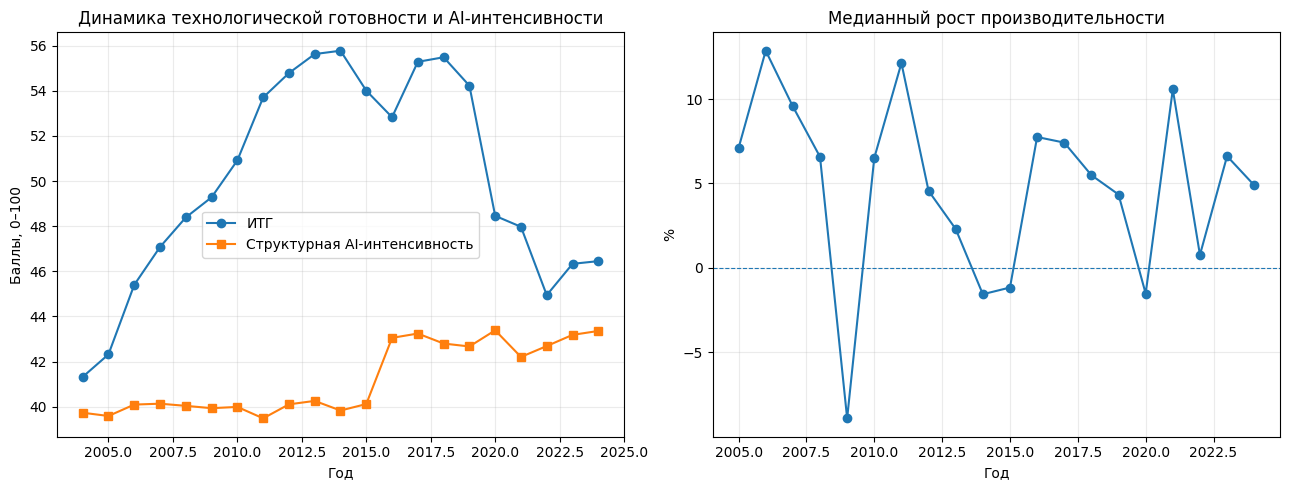

In [13]:
yearly = regional.groupby("year", as_index=False).agg(
    ITG=("ITG_equal_0_100", "mean"),
    structural_AI=("structural_AI_intensity", "mean"),
    productivity_growth=("productivity_growth_pct", "median")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(yearly["year"], yearly["ITG"], marker="o", label="ИТГ")
axes[0].plot(yearly["year"], yearly["structural_AI"], marker="s", label="Структурная AI-интенсивность")
axes[0].set(xlabel="Год", ylabel="Баллы, 0–100", title="Динамика технологической готовности и AI-интенсивности")
axes[0].legend()

axes[1].plot(yearly["year"], yearly["productivity_growth"], marker="o")
axes[1].axhline(0, linewidth=0.8, linestyle="--")
axes[1].set(xlabel="Год", ylabel="%", title="Медианный рост производительности")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "Динамика_ключевых_показателей.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Матрицы и типология регионов

Основная матрица сопоставляет технологическую готовность и AI-экспозицию. Дополнительные матрицы показывают, преобразуются ли готовность и отраслевой потенциал в рост производительности.

In [14]:
latest = regional[regional["year"] == LATEST_YEAR].dropna(subset=[READINESS_MODEL_COL, "structural_AI_intensity"]).copy()

readiness_threshold = latest[READINESS_MODEL_COL].median()
ai_threshold = latest["structural_AI_intensity"].median()

high_readiness = latest[READINESS_MODEL_COL] >= readiness_threshold
high_ai = latest["structural_AI_intensity"] >= ai_threshold

conditions = [high_readiness & high_ai, ~high_readiness & high_ai, high_readiness & ~high_ai]
types = [
    "Высокая готовность и высокая AI-интенсивность",
    "Высокая AI-интенсивность при ограниченной готовности",
    "Высокая готовность при низкой AI-интенсивности"
]

latest["region_type"] = np.select(conditions, types, default="Низкая готовность и низкая AI-интенсивность")

grp_log = np.log1p(latest["grp_real_2024_mln_rub"])
grp_range = grp_log.max() - grp_log.min()
latest["bubble_size"] = 70 + 500 * (grp_log - grp_log.min()) / grp_range if grp_range > 0 else 180

print("Порог ИТГ:", round(readiness_threshold, 2))
print("Порог структурной AI-интенсивности:", round(ai_threshold, 2))

type_counts = latest["region_type"].value_counts().rename_axis("Тип региона").reset_index(name="Количество регионов")
display(type_counts)

Порог ИТГ: 45.27
Порог структурной AI-интенсивности: 45.88


,Тип региона,Количество регионов
0,Высокая готовность и высокая AI-интенсивность,24
1,Низкая готовность и низкая AI-интенсивность,23
2,Высокая готовность при низкой AI-интенсивности,16
3,Высокая AI-интенсивность при ограниченной гото...,16


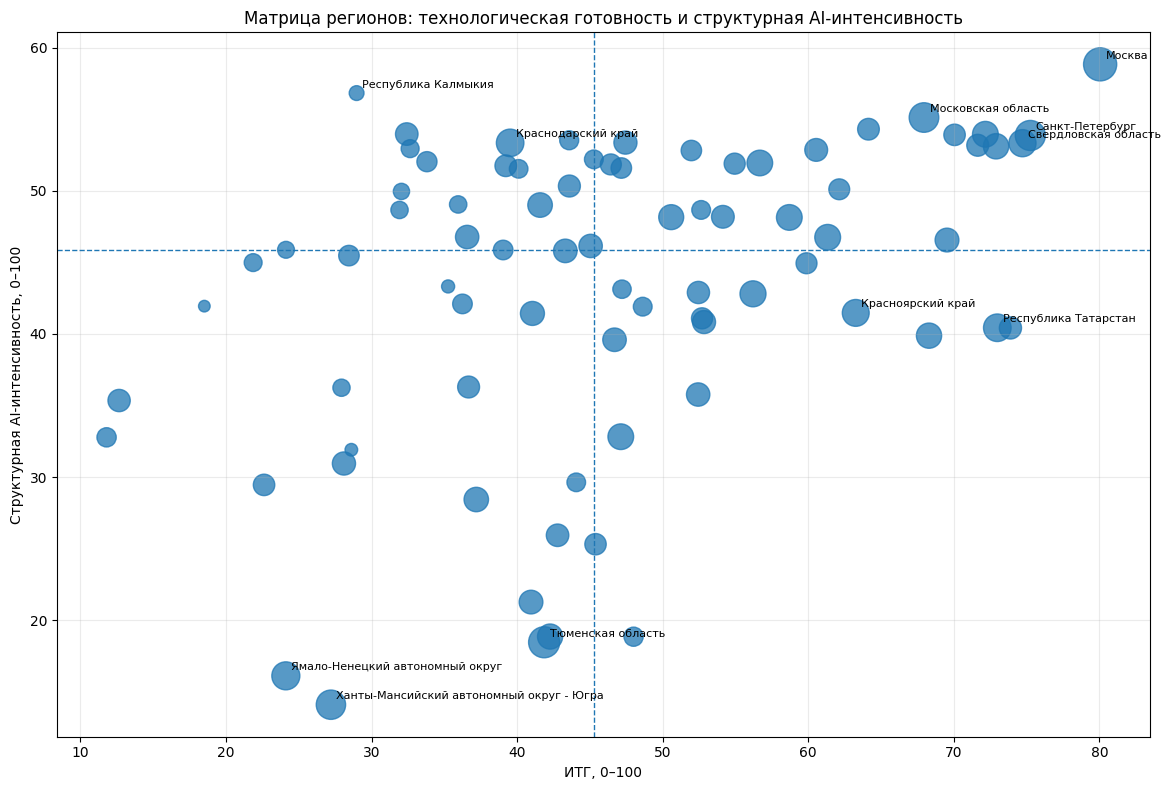

In [15]:
def plot_matrix(data, x, y, x_thr, y_thr, x_label, y_label, title, filename):
    fig, ax = plt.subplots(figsize=(12, 8))

    ax.scatter(data[x], data[y], s=data["bubble_size"], alpha=0.75)

    label_idx = set(data.nlargest(10, "grp_real_2024_mln_rub").index)
    label_idx |= set(data.nlargest(3, x).index)
    label_idx |= set(data.nlargest(3, y).index)

    for i in label_idx:
        row = data.loc[i]
        ax.annotate(row["region"], (row[x], row[y]), xytext=(4, 4), textcoords="offset points", fontsize=8)

    ax.axvline(x_thr, linestyle="--", linewidth=1)
    ax.axhline(y_thr, linestyle="--", linewidth=1)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()


plot_matrix(
    latest,
    READINESS_MODEL_COL,
    "structural_AI_intensity",
    readiness_threshold,
    ai_threshold,
    "ИТГ, 0–100",
    "Структурная AI-интенсивность, 0–100",
    "Матрица регионов: технологическая готовность и структурная AI-интенсивность",
    "Матрица_ИТГ_структурная_AI.png")

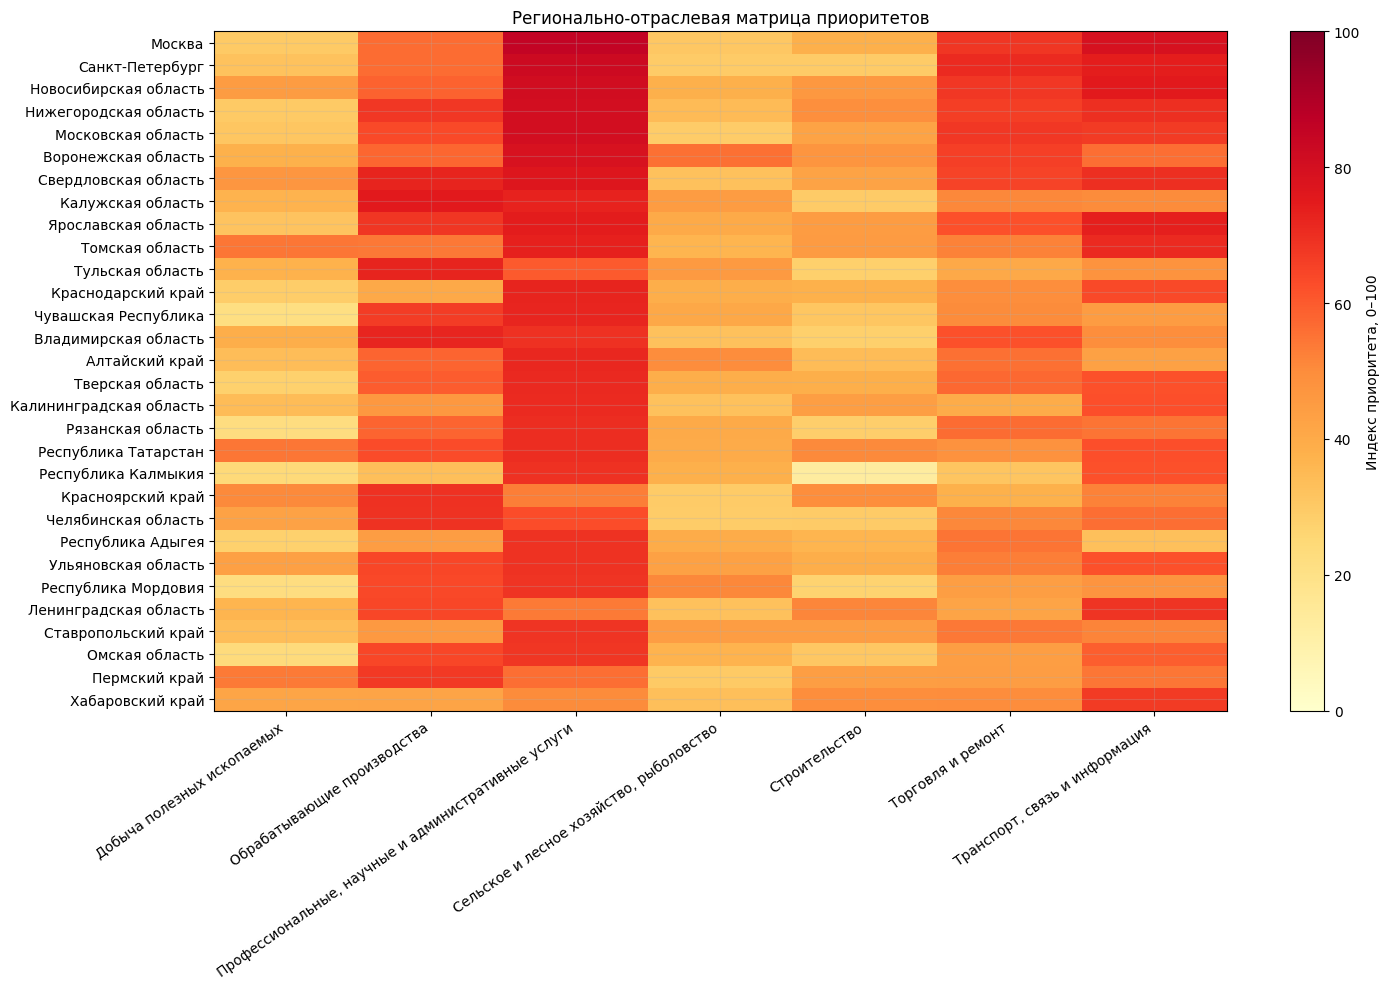

In [16]:
priority_rows = []

for _, reg in latest.iterrows():
    for _, sec in sector_exposure.iterrows():
        col = f'grp_industry_{sec["vrp_sector"]}_real_2024'
        if col not in latest.columns:
            continue

        share = reg[col] / reg["grp_real_2024_mln_rub"] if reg["grp_real_2024_mln_rub"] > 0 else np.nan

        priority_rows.append({
            "region": reg["region"],
            "vrp_sector": sec["vrp_sector"],
            "sector_name": sec["sector_name"],
            "ITG": reg[READINESS_MODEL_COL],
            "sector_AI_intensity": sec["sector_AI_intensity"],
            "sector_share": share
        })

priority_long = pd.DataFrame(priority_rows)

priority_long["share_score"] = priority_long.groupby("vrp_sector")["sector_share"].rank(pct=True) * 100
priority_long["priority_index"] = priority_long[["ITG", "sector_AI_intensity", "share_score"]].mean(axis=1)

priority_pivot = priority_long.pivot(index="region", columns="sector_name", values="priority_index")

top_regions = priority_long.groupby("region")["priority_index"].max().sort_values(ascending=False).head(30).index
priority_pivot = priority_pivot.loc[top_regions]

fig, ax = plt.subplots(figsize=(15, 10))
image = ax.imshow(priority_pivot.to_numpy(), aspect="auto", vmin=0, vmax=100, cmap="YlOrRd")

ax.set_xticks(range(len(priority_pivot.columns)))
ax.set_xticklabels(priority_pivot.columns, rotation=35, ha="right")
ax.set_yticks(range(len(priority_pivot.index)))
ax.set_yticklabels(priority_pivot.index)

ax.set_title("Регионально-отраслевая матрица приоритетов")
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Индекс приоритета, 0–100")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "Регионально_отраслевая_матрица_приоритетов.png", dpi=200, bbox_inches="tight")
plt.show()

# **7. PMG**

## 1) PMG–ARDL: параметры и подготовка данных

In [23]:
from scipy.optimize import minimize
from scipy.stats import norm, chi2
from statsmodels.tsa.stattools import adfuller

PMG_Y = "ln_productivity"
PMG_ITG = READINESS_MODEL_COL
PMG_AI = "structural_AI_intensity"
PMG_X = ["ITG_10", "structural_AI_10"]

PMG_BOOTSTRAP = 30
PMG_CONFIDENCE = 0.95
PMG_RANDOM_STATE = 42
PMG_MIN_COVERAGE = MIN_AI_COVERAGE

PMG_LABELS = {
    "ITG_10": "ИТГ: увеличение на 10 пунктов",
    "structural_AI_10": "Структурная AI-интенсивность: увеличение на 10 пунктов"
}

required_cols = ["region", "year", PMG_Y, PMG_ITG, PMG_AI, "sector_coverage"]
missing_cols = [col for col in required_cols if col not in regional.columns]

if missing_cols:
    raise KeyError("Для PMG отсутствуют столбцы: " + ", ".join(missing_cols))

pmg_source = regional.loc[
    regional["sector_coverage"] >= PMG_MIN_COVERAGE,
    required_cols
].copy()

pmg_source["ITG_10"] = pmg_source[PMG_ITG] / 10
pmg_source["structural_AI_10"] = pmg_source[PMG_AI] / 10

pmg_source = (
    pmg_source.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["region", "year", PMG_Y, *PMG_X])
    .sort_values(["region", "year"])
    .reset_index(drop=True)
)

print("Панель для PMG")
print("Наблюдений:", len(pmg_source))
print("Регионов:", pmg_source["region"].nunique())
print("Период:", int(pmg_source["year"].min()), "–", int(pmg_source["year"].max()))
print("Минимальное покрытие:", f"{PMG_MIN_COVERAGE:.0%}")

Панель для PMG
Наблюдений: 1589
Регионов: 78
Период: 2004 – 2024
Минимальное покрытие: 60%


## 2) Панельные Fisher–ADF-тесты

In [24]:
def panel_fisher_adf(data, variable, diff_order=0, min_obs=7):
    p_values = []

    for _, group in data.groupby("region"):
        series = group.sort_values("year")[variable].dropna().astype(float)

        for _ in range(diff_order):
            series = series.diff().dropna()

        if len(series) < min_obs or series.std() < 1e-10:
            continue

        try:
            max_lag = min(2, max(0, len(series) // 4))
            regression = "ct" if diff_order == 0 else "c"
            p_value = adfuller(series, maxlag=max_lag, regression=regression, autolag="AIC")[1]
            p_values.append(max(float(p_value), 1e-12))
        except Exception:
            continue

    if not p_values:
        return {
            "Переменная": variable,
            "Разность": diff_order,
            "Регионов": 0,
            "Fisher ADF": np.nan,
            "p-value": np.nan
        }

    statistic = -2 * np.sum(np.log(p_values))
    p_value = 1 - chi2.cdf(statistic, 2 * len(p_values))

    return {
        "Переменная": variable,
        "Разность": diff_order,
        "Регионов": len(p_values),
        "Fisher ADF": statistic,
        "p-value": p_value
    }


unit_root_rows = []

for variable in [PMG_Y, *PMG_X]:
    for diff_order in [0, 1, 2]:
        unit_root_rows.append(panel_fisher_adf(pmg_source, variable, diff_order))

pmg_unit_root_tests = pd.DataFrame(unit_root_rows)

print("Панельные Fisher–ADF-тесты")
print("Нулевая гипотеза: переменная содержит единичный корень.")
display(pmg_unit_root_tests.round(4))

Панельные Fisher–ADF-тесты
Нулевая гипотеза: переменная содержит единичный корень.


,Переменная,Разность,Регионов,Fisher ADF,p-value
0,ln_productivity,0,76,552.7378,0.0000
1,ln_productivity,1,76,"1,357.6903",0.0000
2,ln_productivity,2,76,"1,904.3223",0.0000
3,ITG_10,0,76,161.6892,0.2802
4,ITG_10,1,76,"1,265.2287",0.0000
5,ITG_10,2,76,"2,267.2090",0.0000
6,structural_AI_10,0,76,296.1250,0.0000
7,structural_AI_10,1,76,"1,357.1104",0.0000
8,structural_AI_10,2,76,"2,039.6854",0.0000


## 3) Формирование ECM-панели

In [25]:
def make_ecm_panel(data, min_years=7):
    frames = []

    for region, group in data.groupby("region"):
        group = group[["region", "year", PMG_Y, *PMG_X]].dropna().sort_values("year").copy()

        if len(group) < min_years:
            continue

        group["year_gap"] = group["year"].diff()
        group["dy"] = group[PMG_Y].diff()
        group["y_lag"] = group[PMG_Y].shift(1)

        for col in PMG_X:
            group[f"d_{col}"] = group[col].diff()
            group[f"{col}_lag"] = group[col].shift(1)

        required = ["dy", "y_lag", *[f"{col}_lag" for col in PMG_X], *[f"d_{col}" for col in PMG_X]]
        group = group[(group["year_gap"] == 1) & group[required].notna().all(axis=1)]

        if len(group) >= 6:
            frames.append(group[["region", "year", *required]])

    if not frames:
        raise ValueError("После формирования лагов не осталось достаточного числа наблюдений.")

    return pd.concat(frames, ignore_index=True)


pmg_ecm = make_ecm_panel(pmg_source)

print("ECM-панель")
print("Наблюдений:", len(pmg_ecm))
print("Регионов:", pmg_ecm["region"].nunique())

display(pmg_ecm.head())

ECM-панель
Наблюдений: 1502
Регионов: 76


,region,year,dy,y_lag,ITG_10_lag,structural_AI_10_lag,d_ITG_10,d_structural_AI_10
0,Алтайский край,2005,0.0521,6.1032,2.5487,3.7035,0.6903,0.2987
1,Алтайский край,2006,0.1680,6.1553,3.2391,4.0022,0.2249,0.0593
2,Алтайский край,2007,0.1513,6.3234,3.4639,4.0615,0.0983,0.0241
3,Алтайский край,2008,0.0166,6.4747,3.5622,4.0856,-0.6157,0.0384
4,Алтайский край,2009,-0.0519,6.4913,2.9466,4.1240,-0.0529,-0.1799


## 4) Mean Group: предварительные региональные оценки

In [26]:
def estimate_mean_group(data):
    rows = []
    k = len(PMG_X)

    for region, group in data.groupby("region"):
        y = group["dy"].to_numpy(float)
        X = np.column_stack([
            np.ones(len(group)),
            group["y_lag"].to_numpy(float),
            *[group[f"{col}_lag"].to_numpy(float) for col in PMG_X],
            *[group[f"d_{col}"].to_numpy(float) for col in PMG_X]
        ])

        if len(y) <= X.shape[1]:
            continue

        coef = np.linalg.lstsq(X, y, rcond=None)[0]
        phi = coef[1]

        if not np.isfinite(phi) or abs(phi) < 1e-5:
            continue

        long_run = -coef[2:2 + k] / phi

        if not np.all(np.isfinite(long_run)):
            continue

        row = {"region": region, "error_correction": phi, "n_obs": len(group)}

        for i, col in enumerate(PMG_X):
            row[f"long_run_{col}"] = long_run[i]
            row[f"short_run_d_{col}"] = coef[2 + k + i]

        rows.append(row)

    return pd.DataFrame(rows)


mg_region_results = estimate_mean_group(pmg_ecm)

if mg_region_results.empty:
    raise RuntimeError("Не удалось получить оценки Mean Group.")

mg_long_run_cols = [f"long_run_{col}" for col in PMG_X]
mg_start = mg_region_results[mg_long_run_cols].replace([np.inf, -np.inf], np.nan).median().to_numpy(float)
mg_start = np.clip(mg_start, -1, 1)

print("Региональных MG-оценок:", len(mg_region_results))
print("Стартовые значения для PMG:", dict(zip(PMG_X, mg_start.round(4))))

display(mg_region_results.head().round(4))

Региональных MG-оценок: 76
Стартовые значения для PMG: {'ITG_10': np.float64(-0.0669), 'structural_AI_10': np.float64(0.5693)}


,region,error_correction,n_obs,long_run_ITG_10,short_run_d_ITG_10,long_run_structural_AI_10,short_run_d_structural_AI_10
0,Алтайский край,-0.4253,20,0.0057,0.0038,0.6187,0.0199
1,Амурская область,0.1011,20,0.5459,-0.0106,-0.1088,-0.0837
2,Архангельская область,-0.0444,20,-0.3075,0.0324,0.2986,-0.2235
3,Астраханская область,-0.4209,20,-0.0067,-0.0102,-0.5095,-0.2083
4,Белгородская область,-0.3691,20,0.1173,-0.0207,-0.1359,-0.3403


## 5) Оценка PMG


In [27]:
def fit_pmg(data, start=None, bounds=None):
    groups = [(region, group.copy()) for region, group in data.groupby("region")]
    k = len(PMG_X)

    if start is None:
        start = np.zeros(k)

    if bounds is None:
        bounds = [(-3, 3)] * k

    def objective(theta, return_regions=False):
        criterion = 0
        region_rows = []

        for region, group in groups:
            dy = group["dy"].to_numpy(float)
            y_lag = group["y_lag"].to_numpy(float)
            x_lag = group[[f"{col}_lag" for col in PMG_X]].to_numpy(float)
            dx = group[[f"d_{col}" for col in PMG_X]].to_numpy(float)

            ect = y_lag - x_lag @ theta
            X = np.column_stack([np.ones(len(group)), ect, dx])
            coef = np.linalg.lstsq(X, dy, rcond=None)[0]
            residuals = dy - X @ coef
            rss = max(float(residuals @ residuals), 1e-12)

            criterion += len(group) * np.log(rss / len(group))

            if return_regions:
                row = {
                    "region": region,
                    "intercept": coef[0],
                    "error_correction": coef[1],
                    "n_obs": len(group),
                    "sigma2": rss / len(group)
                }

                for i, col in enumerate(PMG_X):
                    row[f"short_run_d_{col}"] = coef[2 + i]

                region_rows.append(row)

        if return_regions:
            return criterion, pd.DataFrame(region_rows)

        return criterion

    starts = [np.asarray(start, float), np.zeros(k)]

    for i in range(k):
        positive = np.zeros(k)
        negative = np.zeros(k)
        positive[i] = 0.05
        negative[i] = -0.05
        starts.extend([positive, negative])

    results = []

    for initial in starts:
        try:
            result = minimize(
                objective,
                initial,
                method="L-BFGS-B",
                bounds=bounds,
                options={"maxiter": 3000, "ftol": 1e-12}
            )

            if np.isfinite(result.fun):
                results.append(result)

        except Exception:
            continue

    if not results:
        raise RuntimeError("Оптимизация PMG завершилась неудачно.")

    best = min(results, key=lambda result: result.fun)
    criterion, region_parameters = objective(best.x, return_regions=True)

    return {
        "theta": best.x,
        "objective": criterion,
        "success": best.success,
        "message": best.message,
        "region_parameters": region_parameters,
        "optimizer": best
    }


pmg_result = fit_pmg(pmg_ecm, start=mg_start)

print("PMG-оптимизация")
print("Успех:", pmg_result["success"])
print("Сообщение:", pmg_result["message"])
print("Долгосрочные коэффициенты:", dict(zip(PMG_X, pmg_result["theta"].round(4))))

display(pmg_result["region_parameters"].head().round(4))

PMG-оптимизация
Успех: True
Сообщение: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Долгосрочные коэффициенты: {'ITG_10': np.float64(-0.0489), 'structural_AI_10': np.float64(0.6398)}


,region,intercept,error_correction,n_obs,sigma2,short_run_d_ITG_10,short_run_d_structural_AI_10
0,Алтайский край,1.4094,-0.3357,20,0.0027,-0.0072,0.0001
1,Амурская область,-0.0560,0.0231,20,0.0043,0.0226,-0.1203
2,Архангельская область,0.2367,-0.0340,20,0.0030,0.0388,-0.2253
3,Астраханская область,0.0839,-0.0080,20,0.0108,-0.0158,-0.1798
4,Белгородская область,0.7086,-0.1235,20,0.0029,-0.0199,-0.3472


## 6) Кластерный bootstrap PMG по регионам

In [28]:
def bootstrap_pmg(data, n_bootstrap=PMG_BOOTSTRAP, random_state=PMG_RANDOM_STATE, start=None):
    rng = np.random.default_rng(random_state)
    regions = data["region"].unique()
    theta_draws, phi_draws = [], []
    failures = 0

    for _ in range(n_bootstrap):
        sampled = rng.choice(regions, size=len(regions), replace=True)
        blocks = []

        for i, region in enumerate(sampled):
            block = data[data["region"] == region].copy()
            block["region"] = f"B{i:04d}"
            blocks.append(block)

        bootstrap_panel = pd.concat(blocks, ignore_index=True)

        try:
            result = fit_pmg(bootstrap_panel, start=start)
            theta_draws.append(result["theta"])
            phi_draws.append(result["region_parameters"]["error_correction"].mean())
        except Exception:
            failures += 1

    if len(theta_draws) < 30:
        raise RuntimeError("Получено слишком мало успешных bootstrap-оценок.")

    return {
        "theta": np.asarray(theta_draws),
        "mean_phi": np.asarray(phi_draws),
        "failures": failures
    }


pmg_bootstrap = bootstrap_pmg(pmg_ecm, start=pmg_result["theta"])

print("Успешных bootstrap-оценок:", len(pmg_bootstrap["theta"]))
print("Неудачных повторов:", pmg_bootstrap["failures"])

Успешных bootstrap-оценок: 30
Неудачных повторов: 0


##7) Долгосрочные коэффициенты PMG


In [29]:
alpha = 1 - PMG_CONFIDENCE
lower_q, upper_q = alpha / 2, 1 - alpha / 2
long_run_rows = []

for i, variable in enumerate(PMG_X):
    coefficient = pmg_result["theta"][i]
    bootstrap_values = pmg_bootstrap["theta"][:, i]
    bootstrap_se = bootstrap_values.std(ddof=1)

    z_value = coefficient / bootstrap_se if bootstrap_se > 0 else np.nan
    p_value = 2 * (1 - norm.cdf(abs(z_value))) if np.isfinite(z_value) else np.nan
    confidence_low, confidence_high = np.quantile(bootstrap_values, [lower_q, upper_q])

    long_run_rows.append({
        "Переменная": PMG_LABELS[variable],
        "Коэффициент PMG": coefficient,
        "Bootstrap SE": bootstrap_se,
        "z": z_value,
        "p-value": p_value,
        f"Нижняя граница {PMG_CONFIDENCE:.0%}": confidence_low,
        f"Верхняя граница {PMG_CONFIDENCE:.0%}": confidence_high,
        "Изменение производительности, %": 100 * (np.exp(coefficient) - 1)
    })

pmg_long_run_table = pd.DataFrame(long_run_rows)

print("Общие долгосрочные коэффициенты PMG")
display(pmg_long_run_table.round(4))

Общие долгосрочные коэффициенты PMG


,Переменная,Коэффициент PMG,Bootstrap SE,z,p-value,Нижняя граница 95%,Верхняя граница 95%,"Изменение производительности, %"
0,ИТГ: увеличение на 10 пунктов,-0.0489,0.0277,-1.7642,0.0777,-0.0986,-0.0046,-4.7766
1,Структурная AI-интенсивность: увеличение на 10...,0.6398,0.0604,10.5857,0.0000,0.5055,0.7398,89.6085


## 8) Скорость коррекции ошибки

In [30]:
pmg_region_parameters = pmg_result["region_parameters"].copy()

phi = pmg_region_parameters["error_correction"]
mean_phi = phi.mean()
median_phi = phi.median()
negative_phi_share = (phi < 0).mean()

phi_boot = pmg_bootstrap["mean_phi"]
phi_se = phi_boot.std(ddof=1)
phi_z = mean_phi / phi_se if phi_se > 0 else np.nan
phi_p = 2 * (1 - norm.cdf(abs(phi_z))) if np.isfinite(phi_z) else np.nan
phi_low, phi_high = np.quantile(phi_boot, [lower_q, upper_q])

pmg_error_correction_table = pd.DataFrame({
    "Показатель": [
        "Средняя скорость коррекции",
        "Медианная скорость коррекции",
        "Доля регионов с отрицательным ECT",
        f"Нижняя граница {PMG_CONFIDENCE:.0%}",
        f"Верхняя граница {PMG_CONFIDENCE:.0%}",
        "p-value средней скорости"
    ],
    "Значение": [
        mean_phi,
        median_phi,
        negative_phi_share,
        phi_low,
        phi_high,
        phi_p]})

print("Диагностика механизма коррекции ошибки")
display(pmg_error_correction_table.round(4))

Диагностика механизма коррекции ошибки


,Показатель,Значение
0,Средняя скорость коррекции,-0.1272
1,Медианная скорость коррекции,-0.0908
2,Доля регионов с отрицательным ECT,0.8947
3,Нижняя граница 95%,-0.1662
4,Верхняя граница 95%,-0.0961
5,p-value средней скорости,0.0000


## 9) Сравнение PMG и Mean Group

In [31]:
mg_matrix = mg_region_results[mg_long_run_cols].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)

if len(mg_matrix) < 3:
    raise RuntimeError("Недостаточно региональных MG-оценок для сравнения с PMG.")

mg_theta = mg_matrix.mean(axis=0)
mg_cov = np.atleast_2d(np.cov(mg_matrix, rowvar=False, ddof=1)) / len(mg_matrix)
pmg_cov = np.atleast_2d(np.cov(pmg_bootstrap["theta"], rowvar=False, ddof=1))

difference = mg_theta - pmg_result["theta"]
cov_difference = mg_cov - pmg_cov

try:
    hausman_stat = float(difference.T @ np.linalg.pinv(cov_difference) @ difference)
    if hausman_stat < 0:
        hausman_stat = np.nan
except Exception:
    hausman_stat = np.nan

hausman_p = 1 - chi2.cdf(hausman_stat, df=len(PMG_X)) if np.isfinite(hausman_stat) else np.nan

pmg_mg_comparison = pd.DataFrame({
    "Переменная": [PMG_LABELS[col] for col in PMG_X],
    "PMG": pmg_result["theta"],
    "Mean Group": mg_theta
})

print("Сравнение PMG и Mean Group")
display(pmg_mg_comparison.round(4))

if np.isfinite(hausman_stat):
    print(f"Приближённый тест Хаусмана: χ² = {hausman_stat:.4f}, p-value = {hausman_p:.4f}")
else:
    print("Тест Хаусмана не удалось надёжно рассчитать.")

Сравнение PMG и Mean Group


,Переменная,PMG,Mean Group
0,ИТГ: увеличение на 10 пунктов,-0.0489,2.0450
1,Структурная AI-интенсивность: увеличение на 10...,0.6398,0.8412


Приближённый тест Хаусмана: χ² = 1.1615, p-value = 0.5595


## 10) Проверка стационарности долгосрочного остатка

In [32]:
cointegration_panel = pmg_source[["region", "year", PMG_Y, *PMG_X]].copy()

cointegration_panel["long_run_residual"] = (
    cointegration_panel[PMG_Y]
    - cointegration_panel[PMG_X].to_numpy(float) @ pmg_result["theta"]
)

cointegration_panel["long_run_residual"] -= (
    cointegration_panel.groupby("region")["long_run_residual"].transform("mean")
)

pmg_residual_adf = panel_fisher_adf(
    cointegration_panel,
    "long_run_residual",
    diff_order=0
)

print("Fisher–ADF для долгосрочного остатка")
display(pd.DataFrame([pmg_residual_adf]).round(4))

Fisher–ADF для долгосрочного остатка


,Переменная,Разность,Регионов,Fisher ADF,p-value
0,long_run_residual,0,76,349.3245,0.0000


## 11) Визуализация результатов PMG

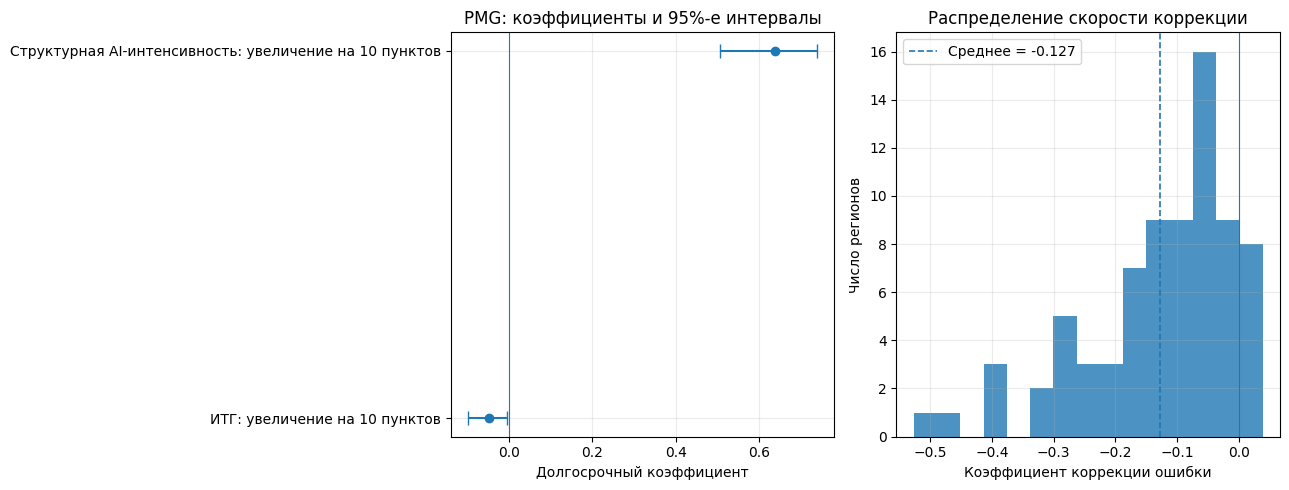

In [33]:
plot_table = pmg_long_run_table.copy()
y_pos = np.arange(len(plot_table))

coef = plot_table["Коэффициент PMG"].to_numpy()
lower = plot_table[f"Нижняя граница {PMG_CONFIDENCE:.0%}"].to_numpy()
upper = plot_table[f"Верхняя граница {PMG_CONFIDENCE:.0%}"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].errorbar(coef, y_pos, xerr=[coef - lower, upper - coef], fmt="o", capsize=5)
axes[0].axvline(0, linewidth=0.8)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(plot_table["Переменная"])
axes[0].set_xlabel("Долгосрочный коэффициент")
axes[0].set_title(f"PMG: коэффициенты и {PMG_CONFIDENCE:.0%}-е интервалы")

axes[1].hist(pmg_region_parameters["error_correction"], bins=15, alpha=0.8)
axes[1].axvline(0, linewidth=0.8)
axes[1].axvline(mean_phi, linestyle="--", linewidth=1.2, label=f"Среднее = {mean_phi:.3f}")
axes[1].set_xlabel("Коэффициент коррекции ошибки")
axes[1].set_ylabel("Число регионов")
axes[1].set_title("Распределение скорости коррекции")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "PMG_коэффициенты_и_ECT.png", dpi=200, bbox_inches="tight")
plt.show()

## 12) Краткая интерпретация PMG

In [34]:
print("=" * 60)
print("КРАТКАЯ ИНТЕРПРЕТАЦИЯ PMG")
print("=" * 60)

if mean_phi < 0 and phi_p < 0.05:
    print(f"Механизм коррекции подтверждён: за год устраняется около {abs(mean_phi) * 100:.1f}% отклонения.")
else:
    print("Статистически значимый механизм коррекции не подтверждён.")

for _, row in pmg_long_run_table.iterrows():
    direction = "положительная" if row["Коэффициент PMG"] > 0 else "отрицательная"
    significance = "значимая" if row["p-value"] < 0.05 else "незначимая"

    print(
        f'{row["Переменная"]}: {direction}, {significance} связь; '
        f'коэффициент = {row["Коэффициент PMG"]:.4f}, '
        f'p-value = {row["p-value"]:.4f}.'
    )

if np.isfinite(hausman_p):
    if hausman_p > 0.05:
        print("Тест Хаусмана не отвергает PMG: долгосрочную однородность можно считать допустимой.")
    else:
        print("Тест Хаусмана отвергает долгосрочную однородность: результаты MG следует учитывать.")

КРАТКАЯ ИНТЕРПРЕТАЦИЯ PMG
Механизм коррекции подтверждён: за год устраняется около 12.7% отклонения.
ИТГ: увеличение на 10 пунктов: отрицательная, незначимая связь; коэффициент = -0.0489, p-value = 0.0777.
Структурная AI-интенсивность: увеличение на 10 пунктов: положительная, значимая связь; коэффициент = 0.6398, p-value = 0.0000.
Тест Хаусмана не отвергает PMG: долгосрочную однородность можно считать допустимой.


## 8. Экспорт результатов

In [35]:
PMG_OUTPUT_DIR = TABLES_DIR
PMG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tables_to_save = {
    "PMG_долгосрочные_коэффициенты.csv": pmg_long_run_table,
    "PMG_скорость_коррекции.csv": pmg_error_correction_table,
    "PMG_региональные_параметры.csv": pmg_region_parameters,
    "Mean_Group_региональные_оценки.csv": mg_region_results,
    "PMG_панельные_ADF_тесты.csv": pmg_unit_root_tests,
    "PMG_MG_сравнение.csv": pmg_mg_comparison,
    "PMG_ADF_долгосрочного_остатка.csv": pd.DataFrame([pmg_residual_adf])
}

for filename, table in tables_to_save.items():
    table.to_csv(PMG_OUTPUT_DIR / filename, index=False, encoding="utf-8-sig")

print("PMG-результаты сохранены в:", PMG_OUTPUT_DIR)

PMG-результаты сохранены в: /content/Результаты_регионального_анализа/Таблицы
